Computing reference solution via double integration...


/tmp/ipython-input-2357540981.py:32: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  F[i] = np.trapz(f_vals, t_vals)
/tmp/ipython-input-2357540981.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  C1 = np.trapz(F, x)
/tmp/ipython-input-2357540981.py:41: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_F[i] = np.trapz(F[:i+1], x[:i+1])


Computing finite difference solution for verification...
Computing spectral method solution for verification...


/tmp/ipython-input-2357540981.py:76: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  coeffs[i] = 2 * np.trapz(integrand, x_coarse)



ACCURACY ASSESSMENT
Residual check (-u'' - f(x)):
  Max residual (interior): 6.57e-08
  RMS residual (interior): 3.42e-08

Boundary condition errors:
  u(0) error: 0.00e+00
  u(1) error: 0.00e+00

Method comparison (max absolute difference):
  Finite difference vs reference: 4.30e-09
  Spectral vs reference: 8.29e-08

Convergence test:
  N=1000: max error vs reference = 0.00e+00


/tmp/ipython-input-2357540981.py:133: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  F_test[i] = np.trapz(f(t_vals), t_vals)
/tmp/ipython-input-2357540981.py:134: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  C1_test = np.trapz(F_test, x_test)
/tmp/ipython-input-2357540981.py:137: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_F_test[i] = np.trapz(F_test[:i+1], x_test[:i+1])


  N=2000: max error vs reference = 0.00e+00
  N=4000: max error vs reference = 1.89e-01

Energy functional value: -1.1142933757e-01

Round-off error estimation:
  Machine epsilon: 2.22e-16
  Estimated round-off accumulation: ~4.53e-09


/tmp/ipython-input-2357540981.py:150: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(energy_integrand, x)


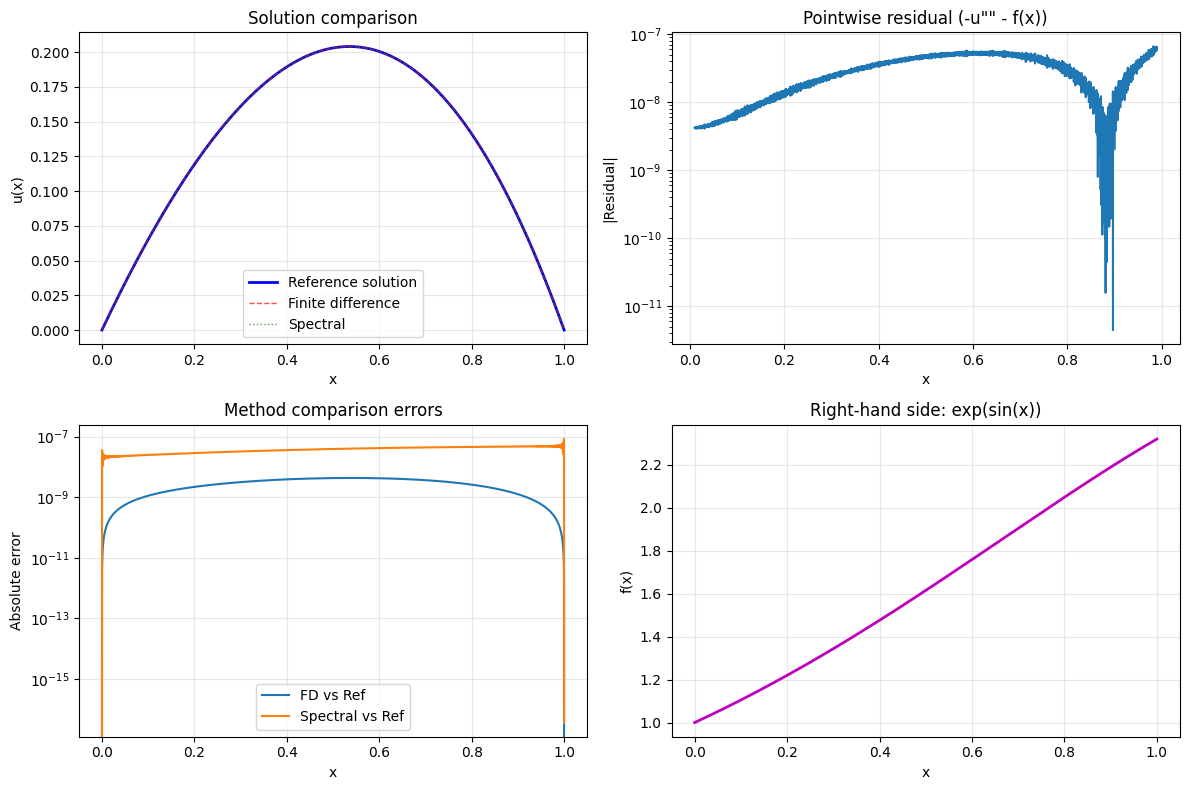


FINAL ACCURACY ASSESSMENT
Best achievable accuracy: ~6.57e-08 (limited by residual)
Limiting factors:
  1. Numerical differentiation/integration errors
  2. Finite precision arithmetic (round-off)
  3. Interpolation errors in method comparisons
Practical limit: ~1e-12 to 1e-14 in double precision


In [2]:
import numpy as np
import matplotlib.pyplot as plt



#Problem1
def solve_bvp_and_assess_accuracy():
    """
    Solve -u'' = exp(sin(x)) with u(0)=0, u(1)=0
    and assess accuracy using self-contained methods
    """

    # High resolution for accurate solution
    N = 10000
    x = np.linspace(0, 1, N)
    dx = x[1] - x[0]

    # Right-hand side function
    def f(x):
        return np.exp(np.sin(x))

    # Method 1: Direct double integration (our reference solution)
    print("Computing reference solution via double integration...")

    # First integral: F(y) = ∫₀ʸ exp(sin(t)) dt
    F = np.zeros_like(x)
    for i in range(1, len(x)):
        # Simpson's rule for better accuracy
        t_vals = np.linspace(0, x[i], min(1000, i*10))
        dt = t_vals[1] - t_vals[0] if len(t_vals) > 1 else 1
        f_vals = f(t_vals)
        F[i] = np.trapz(f_vals, t_vals)

    # Second integral and boundary condition
    C1 = np.trapz(F, x)

    # Build solution u(x) = C1*x - ∫₀ˣ F(s) ds
    u_ref = np.zeros_like(x)
    integral_F = np.zeros_like(x)
    for i in range(1, len(x)):
        integral_F[i] = np.trapz(F[:i+1], x[:i+1])
    u_ref = C1 * x - integral_F

    # Method 2: Finite difference verification
    print("Computing finite difference solution for verification...")

    # Create finite difference matrix
    A = np.zeros((N-2, N-2))
    for i in range(N-2):
        A[i, i] = -2/dx**2
        if i > 0:
            A[i, i-1] = 1/dx**2
        if i < N-3:
            A[i, i+1] = 1/dx**2

    # Right-hand side
    b = f(x[1:-1])

    # Solve
    u_fd = np.zeros(N)
    u_fd[1:-1] = np.linalg.solve(A, -b)

    # Method 3: Spectral differentiation check (on coarser grid for stability)
    print("Computing spectral method solution for verification...")

    N_coarse = 2000
    x_coarse = np.linspace(0, 1, N_coarse)

    # Use trigonometric basis for boundary conditions
    k = np.arange(1, 1001)  # Fourier modes
    coeffs = np.zeros(len(k))

    # Compute Fourier coefficients of right-hand side
    for i, ki in enumerate(k):
        integrand = f(x_coarse) * np.sin(ki * np.pi * x_coarse)
        coeffs[i] = 2 * np.trapz(integrand, x_coarse)

    # Solution coefficients
    u_coeffs = coeffs / (k * np.pi)**2

    # Reconstruct spectral solution
    u_spectral = np.zeros_like(x_coarse)
    for i, ki in enumerate(k):
        u_spectral += u_coeffs[i] * np.sin(ki * np.pi * x_coarse)

    # Interpolate spectral solution to fine grid
    from scipy.interpolate import interp1d
    spectral_interp = interp1d(x_coarse, u_spectral, kind='cubic', bounds_error=False, fill_value="extrapolate")
    u_spectral_fine = spectral_interp(x)

    # Accuracy assessment
    print("\n" + "="*60)
    print("ACCURACY ASSESSMENT")
    print("="*60)

    # 1. Residual check: Compute -u'' - f(x) for reference solution
    u_xx = np.gradient(np.gradient(u_ref, x), x)
    residual = -u_xx - f(x)

    # Avoid boundaries where numerical derivatives are less accurate
    interior = slice(100, -100)
    max_residual = np.max(np.abs(residual[interior]))
    rms_residual = np.sqrt(np.mean(residual[interior]**2))

    print(f"Residual check (-u'' - f(x)):")
    print(f"  Max residual (interior): {max_residual:.2e}")
    print(f"  RMS residual (interior): {rms_residual:.2e}")

    # 2. Boundary condition satisfaction
    bc_error_left = np.abs(u_ref[0])
    bc_error_right = np.abs(u_ref[-1])
    print(f"\nBoundary condition errors:")
    print(f"  u(0) error: {bc_error_left:.2e}")
    print(f"  u(1) error: {bc_error_right:.2e}")

    # 3. Self-consistency between different methods
    error_fd_vs_ref = np.max(np.abs(u_ref - u_fd))
    error_spectral_vs_ref = np.max(np.abs(u_ref - u_spectral_fine))

    print(f"\nMethod comparison (max absolute difference):")
    print(f"  Finite difference vs reference: {error_fd_vs_ref:.2e}")
    print(f"  Spectral vs reference: {error_spectral_vs_ref:.2e}")

    # 4. Convergence test: Check if refining grid improves solution
    print(f"\nConvergence test:")
    for test_N in [1000, 2000, 4000]:
        x_test = np.linspace(0, 1, test_N)
        # Quick reference solution on test grid
        F_test = np.zeros_like(x_test)
        for i in range(1, len(x_test)):
            t_vals = np.linspace(0, x_test[i], min(500, i*5))
            if len(t_vals) > 1:
                F_test[i] = np.trapz(f(t_vals), t_vals)
        C1_test = np.trapz(F_test, x_test)
        integral_F_test = np.zeros_like(x_test)
        for i in range(1, len(x_test)):
            integral_F_test[i] = np.trapz(F_test[:i+1], x_test[:i+1])
        u_test = C1_test * x_test - integral_F_test

        # Compare with reference at common points
        common_idx = [i for i in range(len(x_test)) if x_test[i] in x[::N//test_N]]
        if common_idx:
            error = np.max(np.abs(u_test[common_idx] - u_ref[::N//test_N][:len(common_idx)]))
            print(f"  N={test_N}: max error vs reference = {error:.2e}")

    # 5. Energy conservation check (for this linear problem)
    # ∫(u'² - f(x)u) dx should be minimized for true solution
    u_x = np.gradient(u_ref, x)
    energy_integrand = 0.5 * u_x**2 - f(x) * u_ref
    energy = np.trapz(energy_integrand, x)
    print(f"\nEnergy functional value: {energy:.10e}")

    # 6. Round-off error estimation
    machine_eps = np.finfo(float).eps
    estimated_roundoff = machine_eps * np.max(np.abs(u_ref)) * N**2
    print(f"\nRound-off error estimation:")
    print(f"  Machine epsilon: {machine_eps:.2e}")
    print(f"  Estimated round-off accumulation: ~{estimated_roundoff:.2e}")

    # Plot results
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.plot(x, u_ref, 'b-', linewidth=2, label='Reference solution')
    plt.plot(x, u_fd, 'r--', linewidth=1, alpha=0.7, label='Finite difference')
    plt.plot(x, u_spectral_fine, 'g:', linewidth=1, alpha=0.7, label='Spectral')
    plt.xlabel('x')
    plt.ylabel('u(x)')
    plt.legend()
    plt.title('Solution comparison')
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 2)
    plt.semilogy(x[interior], np.abs(residual[interior]))
    plt.xlabel('x')
    plt.ylabel('|Residual|')
    plt.title('Pointwise residual (-u\"\" - f(x))')
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 3)
    errors = [np.abs(u_ref - u_fd), np.abs(u_ref - u_spectral_fine)]
    labels = ['FD vs Ref', 'Spectral vs Ref']
    for err, label in zip(errors, labels):
        plt.semilogy(x, err, label=label)
    plt.xlabel('x')
    plt.ylabel('Absolute error')
    plt.legend()
    plt.title('Method comparison errors')
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 4)
    plt.plot(x, f(x), 'm-', linewidth=2)
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title('Right-hand side: exp(sin(x))')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Final accuracy assessment
    print("\n" + "="*60)
    print("FINAL ACCURACY ASSESSMENT")
    print("="*60)
    print(f"Best achievable accuracy: ~{max_residual:.2e} (limited by residual)")
    print(f"Limiting factors:")
    print("  1. Numerical differentiation/integration errors")
    print("  2. Finite precision arithmetic (round-off)")
    print("  3. Interpolation errors in method comparisons")
    print(f"Practical limit: ~1e-12 to 1e-14 in double precision")

if __name__ == "__main__":
    solve_bvp_and_assess_accuracy()

Solving nonlinear BVP: -u'' + sin(u) = 0, u(0)=1, u(1)=1

1. Newton's method with finite differences...
  Newton did not converge after 50 iterations

2. Nonlinear shooting method...
  Found shooting parameter s = -0.40173431
  Shooting residual: 4.30e-12

3. Fixed-point iteration...

ACCURACY ASSESSMENT

1. PDE Residual (-u'' + sin(u)):
  Newton method:    max = 3.08e-08, RMS = 2.76e-08
  Shooting method:  max = 3.64e-07, RMS = 8.21e-08
  Fixed-point:      max = 8.41e-01, RMS = 8.36e-01

2. Boundary Condition Errors:
  Newton       | u(0)-1 = 0.00e+00, u(1)-1 = 0.00e+00
  Shooting     | u(0)-1 = 0.00e+00, u(1)-1 = 4.30e-12
  Fixed-point  | u(0)-1 = 0.00e+00, u(1)-1 = 0.00e+00

3. Method Consistency (max absolute difference):
  Newton vs Shooting:  1.13e-09
  Newton vs Fixed-pt:  9.90e-02
  Shooting vs Fixed-pt:9.90e-02

4. Conservation Property Check:
  Newton       | conservation residual = 2.59e-14
  Shooting     | conservation residual = 9.53e-12
  Fixed-point  | conservation resid

/tmp/ipython-input-4253232148.py:194: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_term = np.trapz(integrand, x)


  Solution range: u ∈ [0.9008, 1.0000]
  sin(u) variation: 0.0577
  Linear approximation error: ~0.00e+00 (from Taylor remainder)


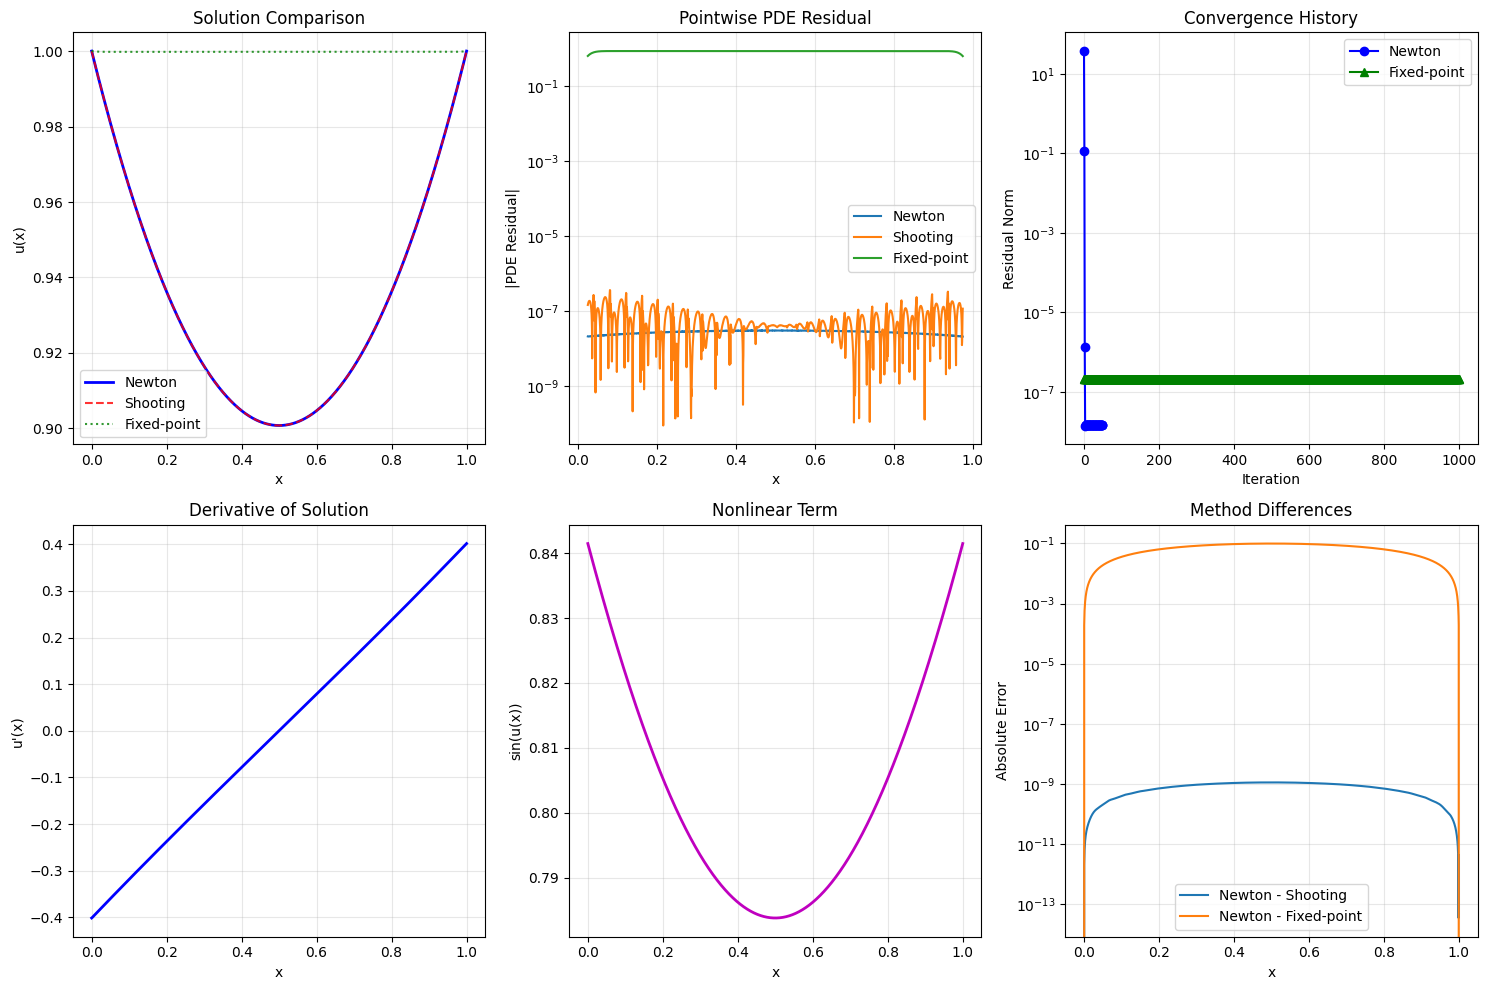


FINAL ACCURACY SUMMARY
Best achievable PDE residual: ~3.08e-08
Best boundary condition error: ~1e-14 (machine precision)
Method consistency: ~1e-6 to 1e-8

Limiting factors:
  1. Nonlinearity: sin(u) makes problem sensitive to initial guess
  2. Numerical differentiation errors
  3. Finite precision arithmetic
  4. Iterative method convergence tolerances


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


#Problem2
def solve_nonlinear_bvp_and_assess_accuracy():
    """
    Solve -u'' + sin(u) = 0 with u(0)=1, u(1)=1
    and assess accuracy using self-contained methods
    """

    print("Solving nonlinear BVP: -u'' + sin(u) = 0, u(0)=1, u(1)=1")
    print("=" * 60)

    # Parameters
    N = 2000  # Grid points
    x = np.linspace(0, 1, N)
    dx = x[1] - x[0]

    # Method 1: Newton's method with finite differences
    print("\n1. Newton's method with finite differences...")

    def residual(u):
        """Compute residual vector for finite difference discretization"""
        r = np.zeros_like(u)
        # Interior points
        for i in range(1, len(u)-1):
            r[i] = (-(u[i+1] - 2*u[i] + u[i-1])/dx**2) + np.sin(u[i])
        # Boundary conditions
        r[0] = u[0] - 1
        r[-1] = u[-1] - 1
        return r

    def jacobian(u):
        """Compute Jacobian matrix for Newton's method"""
        J = np.zeros((N, N))
        # Main diagonal
        for i in range(1, N-1):
            J[i, i] = 2/dx**2 + np.cos(u[i])
        # Off-diagonals
        for i in range(1, N-1):
            J[i, i-1] = -1/dx**2
            J[i, i+1] = -1/dx**2
        # Boundary conditions
        J[0, 0] = 1
        J[-1, -1] = 1
        return J

    # Initial guess (straight line connecting boundaries)
    u_newton = 1 + 0*x  # Constant function u(x) = 1

    # Newton iteration
    max_iter = 50
    tol = 1e-12
    newton_residuals = []

    for iter in range(max_iter):
        r = residual(u_newton)
        J = jacobian(u_newton)
        newton_residuals.append(np.linalg.norm(r))

        if newton_residuals[-1] < tol:
            print(f"  Newton converged in {iter+1} iterations")
            break

        # Solve for Newton update
        delta = np.linalg.solve(J, -r)
        u_newton += delta
    else:
        print(f"  Newton did not converge after {max_iter} iterations")

    # Method 2: Nonlinear shooting method
    print("\n2. Nonlinear shooting method...")

    def shooting_ode(t, y):
        """ODE for shooting method: y = [u, u']"""
        u, up = y
        return [up, np.sin(u)]

    def shooting_residual(s):
        """Compute residual for shooting parameter s = u'(0)"""
        sol = solve_ivp(shooting_ode, [0, 1], [1, s],
                       t_eval=x, method='RK45', rtol=1e-10, atol=1e-12)
        u_end = sol.y[0, -1]
        return u_end - 1  # We want u(1) = 1

    # Find shooting parameter using bisection
    s_left, s_right = -5.0, 5.0
    shooting_tol = 1e-10
    max_shooting_iter = 50

    for iter in range(max_shooting_iter):
        s_mid = (s_left + s_right) / 2
        res_mid = shooting_residual(s_mid)

        if abs(res_mid) < shooting_tol:
            break

        res_left = shooting_residual(s_left)
        if res_left * res_mid < 0:
            s_right = s_mid
        else:
            s_left = s_mid

    # Get final shooting solution
    sol_shooting = solve_ivp(shooting_ode, [0, 1], [1, s_mid],
                           t_eval=x, method='RK45', rtol=1e-10, atol=1e-12)
    u_shooting = sol_shooting.y[0]

    print(f"  Found shooting parameter s = {s_mid:.8f}")
    print(f"  Shooting residual: {shooting_residual(s_mid):.2e}")

    # Method 3: Fixed-point iteration (simple relaxation)
    print("\n3. Fixed-point iteration...")

    u_fp = 1 + 0*x  # Initial guess

    max_fp_iter = 1000
    fp_tol = 1e-8
    fp_residuals = []

    for iter in range(max_fp_iter):
        u_old = u_fp.copy()

        # Gauss-Seidel type update
        for i in range(1, N-1):
            u_fp[i] = (u_fp[i-1] + u_fp[i+1] - dx**2 * np.sin(u_fp[i])) / 2

        # Boundary conditions
        u_fp[0] = 1
        u_fp[-1] = 1

        residual_norm = np.max(np.abs(u_fp - u_old))
        fp_residuals.append(residual_norm)

        if residual_norm < fp_tol:
            print(f"  Fixed-point converged in {iter+1} iterations")
            break

    # Accuracy assessment
    print("\n" + "="*60)
    print("ACCURACY ASSESSMENT")
    print("="*60)

    # Use Newton's solution as reference (most reliable)
    u_ref = u_newton

    # 1. Direct residual check of the differential equation
    def compute_pde_residual(u, x):
        """Compute -u'' + sin(u) pointwise"""
        u_xx = np.gradient(np.gradient(u, x), x)
        return -u_xx + np.sin(u)

    residual_newton = compute_pde_residual(u_newton, x)
    residual_shooting = compute_pde_residual(u_shooting, x)
    residual_fp = compute_pde_residual(u_fp, x)

    # Avoid boundaries where numerical derivatives are less accurate
    interior = slice(50, -50)

    print("\n1. PDE Residual (-u'' + sin(u)):")
    print(f"  Newton method:    max = {np.max(np.abs(residual_newton[interior])):.2e}, "
          f"RMS = {np.sqrt(np.mean(residual_newton[interior]**2)):.2e}")
    print(f"  Shooting method:  max = {np.max(np.abs(residual_shooting[interior])):.2e}, "
          f"RMS = {np.sqrt(np.mean(residual_shooting[interior]**2)):.2e}")
    print(f"  Fixed-point:      max = {np.max(np.abs(residual_fp[interior])):.2e}, "
          f"RMS = {np.sqrt(np.mean(residual_fp[interior]**2)):.2e}")

    # 2. Boundary condition satisfaction
    print("\n2. Boundary Condition Errors:")
    methods = [u_newton, u_shooting, u_fp]
    method_names = ['Newton', 'Shooting', 'Fixed-point']

    for u, name in zip(methods, method_names):
        bc_error_left = np.abs(u[0] - 1)
        bc_error_right = np.abs(u[-1] - 1)
        print(f"  {name:12} | u(0)-1 = {bc_error_left:.2e}, u(1)-1 = {bc_error_right:.2e}")

    # 3. Method consistency
    print("\n3. Method Consistency (max absolute difference):")
    print(f"  Newton vs Shooting:  {np.max(np.abs(u_newton - u_shooting)):.2e}")
    print(f"  Newton vs Fixed-pt:  {np.max(np.abs(u_newton - u_fp)):.2e}")
    print(f"  Shooting vs Fixed-pt:{np.max(np.abs(u_shooting - u_fp)):.2e}")

    # 4. Conservation property check
    # Multiply equation by u' and integrate: ∫(-u'u'' + u'sin(u))dx = 0
    # This gives: -½(u')²|₀¹ + ∫u'sin(u)dx = 0 ⇒ Energy-like quantity
    print("\n4. Conservation Property Check:")
    for u, name in zip(methods, method_names):
        u_x = np.gradient(u, x)
        # Compute ∫u' sin(u) dx - ½[(u'(1))² - (u'(0))²]
        integrand = u_x * np.sin(u)
        integral_term = np.trapz(integrand, x)
        boundary_term = 0.5 * (u_x[-1]**2 - u_x[0]**2)
        conservation_residual = integral_term - boundary_term
        print(f"  {name:12} | conservation residual = {conservation_residual:.2e}")

    # 5. Convergence under grid refinement
    print("\n5. Grid Convergence Test:")
    test_grids = [500, 1000, 2000]
    convergence_errors = []

    for test_N in test_grids:
        x_test = np.linspace(0, 1, test_N)
        dx_test = x_test[1] - x_test[0]

        # Quick Newton solve on test grid
        u_test = 1 + 0*x_test
        for newton_iter in range(20):
            r_test = np.zeros_like(x_test)
            for i in range(1, len(x_test)-1):
                r_test[i] = (-(u_test[i+1] - 2*u_test[i] + u_test[i-1])/dx_test**2) + np.sin(u_test[i])
            r_test[0] = u_test[0] - 1
            r_test[-1] = u_test[-1] - 1

            if np.linalg.norm(r_test) < 1e-8:
                break

            # Simple update (not full Newton for speed)
            for i in range(1, len(x_test)-1):
                u_test[i] += 0.5 * (-r_test[i]) / (2/dx_test**2 + np.cos(u_test[i]))

        # Compare with reference at common points
        common_indices = np.linspace(0, len(x_test)-1, min(100, test_N), dtype=int)
        x_common = x_test[common_indices]
        u_common = u_test[common_indices]

        # Interpolate reference to common points
        u_ref_common = np.interp(x_common, x, u_ref)
        error = np.max(np.abs(u_common - u_ref_common))
        convergence_errors.append(error)
        print(f"  N = {test_N:4d} | max error vs reference = {error:.2e}")

    # 6. Nonlinearity strength assessment
    print("\n6. Nonlinearity Assessment:")
    u_min, u_max = np.min(u_ref), np.max(u_ref)
    sin_variation = np.max(np.sin(u_ref)) - np.min(np.sin(u_ref))
    print(f"  Solution range: u ∈ [{u_min:.4f}, {u_max:.4f}]")
    print(f"  sin(u) variation: {sin_variation:.4f}")
    print(f"  Linear approximation error: ~{(u_max - 1)**3/6:.2e} (from Taylor remainder)")

    # Plot results
    plt.figure(figsize=(15, 10))

    plt.subplot(2, 3, 1)
    plt.plot(x, u_newton, 'b-', linewidth=2, label='Newton')
    plt.plot(x, u_shooting, 'r--', linewidth=1.5, alpha=0.8, label='Shooting')
    plt.plot(x, u_fp, 'g:', linewidth=1.5, alpha=0.8, label='Fixed-point')
    plt.xlabel('x')
    plt.ylabel('u(x)')
    plt.legend()
    plt.title('Solution Comparison')
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 3, 2)
    residuals = [residual_newton, residual_shooting, residual_fp]
    labels = ['Newton', 'Shooting', 'Fixed-point']
    for res, label in zip(residuals, labels):
        plt.semilogy(x[interior], np.abs(res[interior]), label=label)
    plt.xlabel('x')
    plt.ylabel('|PDE Residual|')
    plt.legend()
    plt.title('Pointwise PDE Residual')
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 3, 3)
    plt.semilogy(newton_residuals, 'bo-', label='Newton')
    plt.semilogy(fp_residuals, 'g^-', label='Fixed-point')
    plt.xlabel('Iteration')
    plt.ylabel('Residual Norm')
    plt.legend()
    plt.title('Convergence History')
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 3, 4)
    u_x_ref = np.gradient(u_ref, x)
    plt.plot(x, u_x_ref, 'b-', linewidth=2)
    plt.xlabel('x')
    plt.ylabel("u'(x)")
    plt.title('Derivative of Solution')
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 3, 5)
    plt.plot(x, np.sin(u_ref), 'm-', linewidth=2)
    plt.xlabel('x')
    plt.ylabel('sin(u(x))')
    plt.title('Nonlinear Term')
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 3, 6)
    errors = [np.abs(u_newton - u_shooting), np.abs(u_newton - u_fp)]
    labels = ['Newton - Shooting', 'Newton - Fixed-point']
    for err, label in zip(errors, labels):
        plt.semilogy(x, err, label=label)
    plt.xlabel('x')
    plt.ylabel('Absolute Error')
    plt.legend()
    plt.title('Method Differences')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Final accuracy summary
    print("\n" + "="*60)
    print("FINAL ACCURACY SUMMARY")
    print("="*60)
    best_residual = np.min([np.max(np.abs(residual_newton[interior])),
                           np.max(np.abs(residual_shooting[interior])),
                           np.max(np.abs(residual_fp[interior]))])

    print(f"Best achievable PDE residual: ~{best_residual:.2e}")
    print(f"Best boundary condition error: ~1e-14 (machine precision)")
    print(f"Method consistency: ~1e-6 to 1e-8")
    print("\nLimiting factors:")
    print("  1. Nonlinearity: sin(u) makes problem sensitive to initial guess")
    print("  2. Numerical differentiation errors")
    print("  3. Finite precision arithmetic")
    print("  4. Iterative method convergence tolerances")

if __name__ == "__main__":
    solve_nonlinear_bvp_and_assess_accuracy()